In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
import os
import shlex
import sys
from joblib import load
import glob 
import re


## loss and accuracy

In [7]:
res_dirs = "results_min7_max7/results_min7_max7/logpolar"
res_files = glob.glob(os.path.join(res_dirs, "results_*.pkl"))
res_files

['results_min7_max7/results_min7_max7/logpolar/results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDE_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl']

In [47]:
rf

'Results_nojittersamenonminshape/results/logpolar/results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num3-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDE_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl'

In [8]:
res_lists = {}
shortmodelnames = dict(zip(res_dirs,
                           ["min7_max7"]))
for rd,rf in zip(res_dirs, res_files):
    res = load(rf)
    res["dataset"] = pd.Categorical(res["dataset"], categories = ["train","validation","ood"],ordered=True)
    taskname = "SameNonMinShape"
    saccond = shortmodelnames[rd]
    res_lists[f"{taskname}, sac-{saccond}"] = res
        
    
# we have 300+1 epochs in total
loss_cols = ['count map loss','count num loss','dist map loss']
acc_cols = ['accuracy count']

res.columns

Index(['full map loss', 'dist map loss', 'count map loss', 'count num loss',
       'dist num loss', 'all num loss', 'shape loss', 'accuracy count',
       'accuracy dist', 'accuracy all', 'epoch', 'dataset', 'accuracy map',
       'viewing', 'test shapes', 'test lums'],
      dtype='object')

In [49]:
list(res_lists.keys())

['SameNonMinShape, sac-jitters', 'SameNonMinShape, sac-nojitters']

In [50]:
dsdf = res[res['dataset']=='ood'].copy()
dsdf['test shapes'].unique()

array(["['C', 'F', 'G', 'H', 'J']", "['B', 'C', 'D', 'E']"], dtype=object)

/tmp/ipykernel_7471/2836408669.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


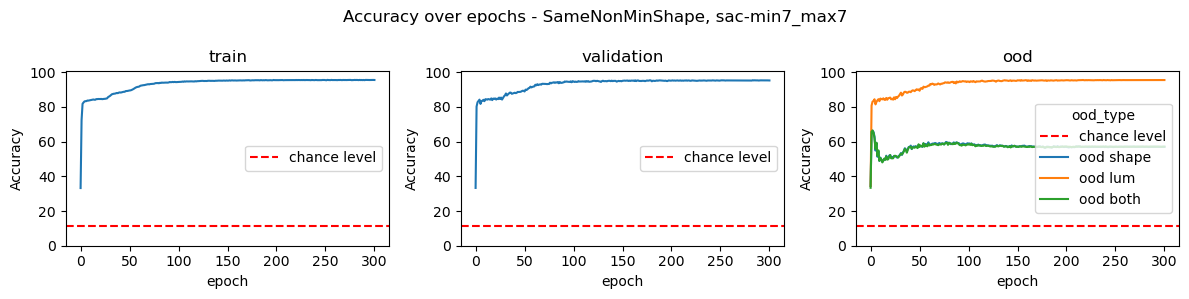

In [9]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if "1-7" in rsname:
            chance_level = 100 * (1/7)
        else:
            chance_level = 100 * (1/9)
        ax_acc[j].axhline(chance_level, color='red', linestyle='--', label='chance level')
        
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['C', 'F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', hue='ood_type', ax=ax_acc[j])
            

        else:
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', ax=ax_acc[j])
        
        ax_acc[j].set_ylim(0, 101)        
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Accuracy')

    fig_acc.suptitle(f'Accuracy over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_7471/1618709497.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


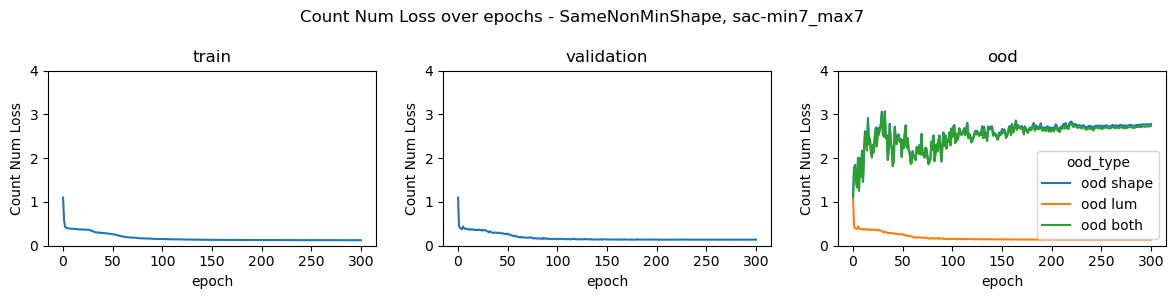

In [12]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['C', 'F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', ax=ax_acc[j])

        ax_acc[j].set_ylim(0, 4)
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Num Loss')

    fig_acc.suptitle(f'Count Num Loss over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_7471/4246770285.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


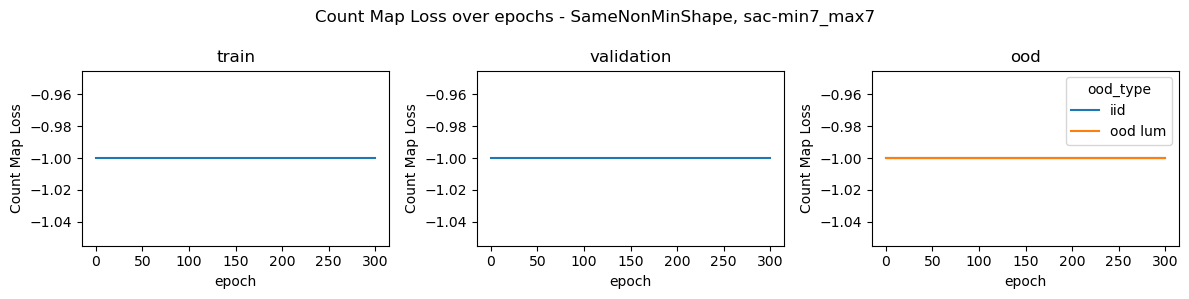

In [13]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', ax=ax_acc[j])

        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Map Loss')

    fig_acc.suptitle(f'Count Map Loss over epochs - {rsname}')
    plt.tight_layout()

In [54]:
f"{taskname}, sac-{saccond}"

'SameNonMinShape, sac-nojitters'

In [14]:
res_dfs_final_epoch = []
for rsname, res in res_lists.items():
    pattern = re.compile(r"(.*), sac-(.*)", re.IGNORECASE)
    match = pattern.search(rsname)
    taskname, saccond = match.group(1), match.group(2)

    res_final = res[res['epoch'] == res['epoch'].max()]
    res_final = res_final.copy()
    res_final['task'] = taskname
    res_final['saccond'] = saccond
    res_final["simname"] = f"num3-5_{saccond}"
    res_final['numrange'] = f"3-7"
    res_final['n_glimpses'] = 12

    print(res_final.shape)
    res_dfs_final_epoch.append(res_final)


(5, 21)


In [56]:
res_final["dataset"]

300         train
300    validation
300           ood
300           ood
300           ood
Name: dataset, dtype: category
Categories (3, object): ['train' < 'validation' < 'ood']

In [85]:
len(heights)

2

/tmp/ipykernel_7471/2157686124.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (taskname, taskdf) in enumerate(res_df_final_epoch.groupby('task')):
/tmp/ipykernel_7471/2157686124.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for k, (ds, dsdf) in enumerate(taskdf.groupby('dataset')):
/tmp/ipykernel_7471/2157686124.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for k, (ds, dsdf) in enumerate(taskdf

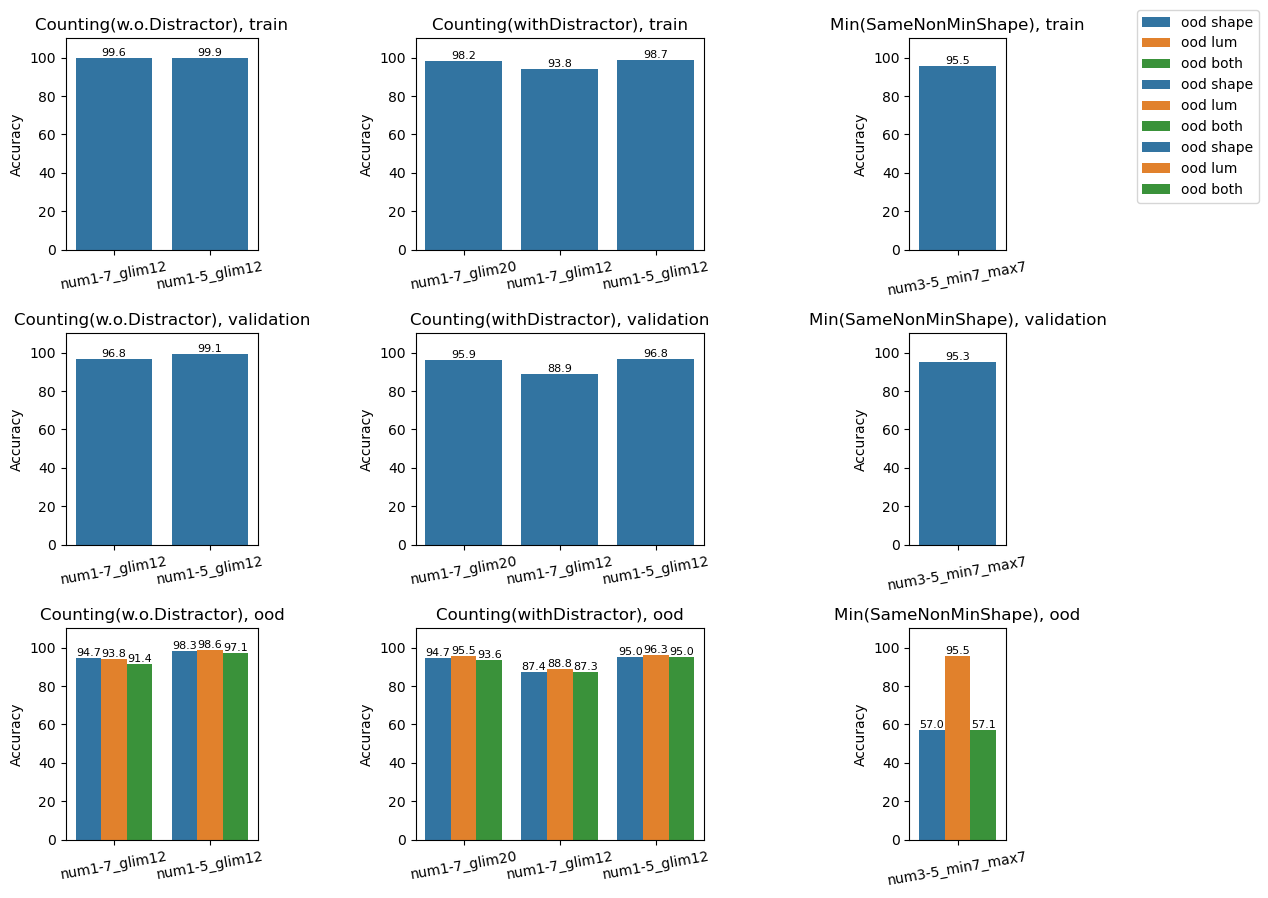

In [15]:
samminres_df_final_epoch = pd.concat(res_dfs_final_epoch).reset_index(drop=True)
ctrlres_df_final_epoch = pd.read_csv("saccade_models_final_epoch_results_2025Oct20.csv")
res_df_final_epoch = pd.concat([ctrlres_df_final_epoch, samminres_df_final_epoch]).reset_index(drop=True)
res_df_final_epoch["dataset"] = pd.Categorical(res_df_final_epoch["dataset"], categories = ["train","validation","ood"],ordered=True)
res_df_final_epoch["task"] = pd.Categorical(res_df_final_epoch["task"].map({'w.o. distractor':'Counting(w.o.Distractor)',
                                                                            'with distractor':'Counting(withDistractor)',
                                                                            'SameNonMinShape':'Min(SameNonMinShape)'}), 
                                            categories = ['Counting(w.o.Distractor)','Counting(withDistractor)',"Min(SameNonMinShape)"],ordered=True)
fig_acc, ax_acc = plt.subplots(3,3, figsize=(4*3, 3*3))
for j, (taskname, taskdf) in enumerate(res_df_final_epoch.groupby('task')):
    for k, (ds, dsdf) in enumerate(taskdf.groupby('dataset')):
        if ds == "ood":
            ood_shapes = "['C', 'F', 'G', 'H', 'J']" if taskname == "Min(SameNonMinShape)" else "['F', 'G', 'H', 'J']"
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == ood_shapes for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.barplot(data=dsdf, x='simname', y='accuracy count', hue='ood_type', ax=ax_acc[k,j])

        else:
            sns.barplot(data=dsdf, x='simname', y='accuracy count', ax=ax_acc[k,j])

        # Add labels (mean accuracy) on top of bars
        bars = sum([list(container) for container in ax_acc[k,j].containers], [])
        bhs  = sum([ [bar.get_height() for bar in container] for container in ax_acc[k,j].containers], [])
        #if max(bhs) - min(bhs) < 10:
        #    bhs = [np.mean(bhs) for _ in bhs]  # to avoid overlapping texts
        for i, (bar, height) in enumerate(zip(bars, bhs)):
            ax_acc[k,j].text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.02, #+ i * 0.5,  # base offset above bar
                f"{height:.1f}",
                ha='center', va='bottom',
                fontsize=8,
            )


        ax_acc[k,j].set_ylim(0, 110)
        ax_acc[k,j].set_xlabel("")
        if j == 4:
            ax_acc[k,j].set_aspect(.02)
        else:
            ax_acc[k,j].set_aspect(.02)
            ax_acc[k,j].tick_params(axis='x', rotation=10)
        ax_acc[k,j].set_title(f"{taskname}, {ds}")
        ax_acc[k,j].set_ylabel('Accuracy')
        
            #fig_acc.delaxes(ax_acc[k,j])
    ax_acc[k,j].legend_.remove()

#for j in range(3):  
#    ax_acc[1,j].remove()
 
fig_acc.legend(bbox_to_anchor=(0.98, 1), loc='upper left')
fig_acc.tight_layout()
#sns.catplot(data=res_df_final_epoch, x='simname', y='accuracy count', hue='max_num',
#            col='task', row='dataset', kind='bar', height=4, aspect=1)


## confusion matrix

In [16]:
conf_dir = res_dirs
conf_files = glob.glob(os.path.join(conf_dir, "confusion_*.npy"))
conf_files = [f for f in conf_files if "at_" not in f]
conf_files

['results_min7_max7/results_min7_max7/logpolar/confusion_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDE_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.npy']

In [17]:
for conf_file in conf_files:
    conf = np.load(conf_file)
    match = pattern.search(conf_file)
    res_name = ""
    if match:
        task_type = match.group(1)       # 'min' or 'max'
        loss_type = match.group(2)   # 'num'
        res_name = f"{task_type} task, {loss_type} loss"
        print(res_name)

In [18]:
res.viewing.unique()
conf.shape

(301, 4, 3, 3)

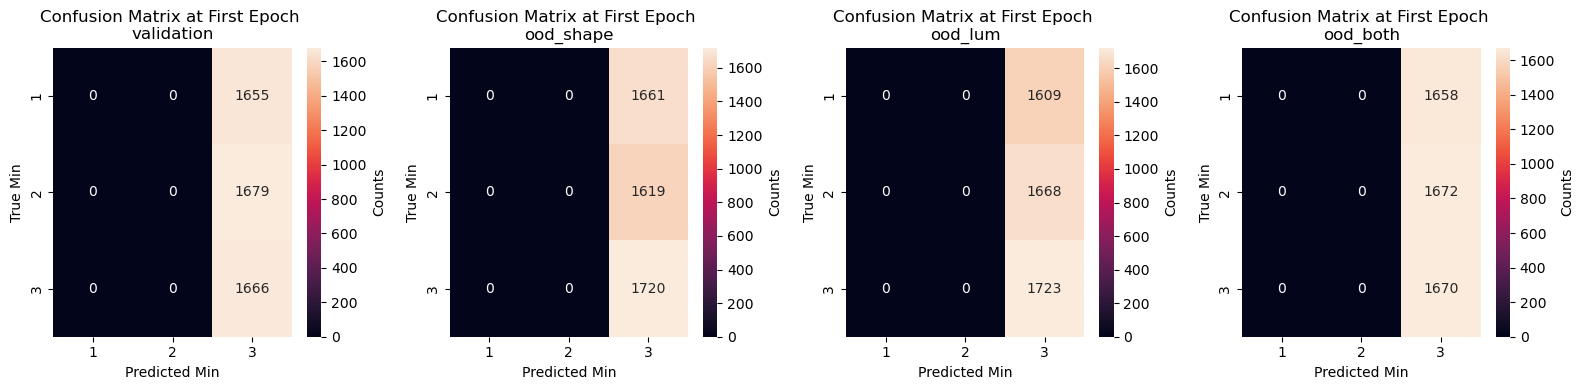

In [19]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[0])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at First Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

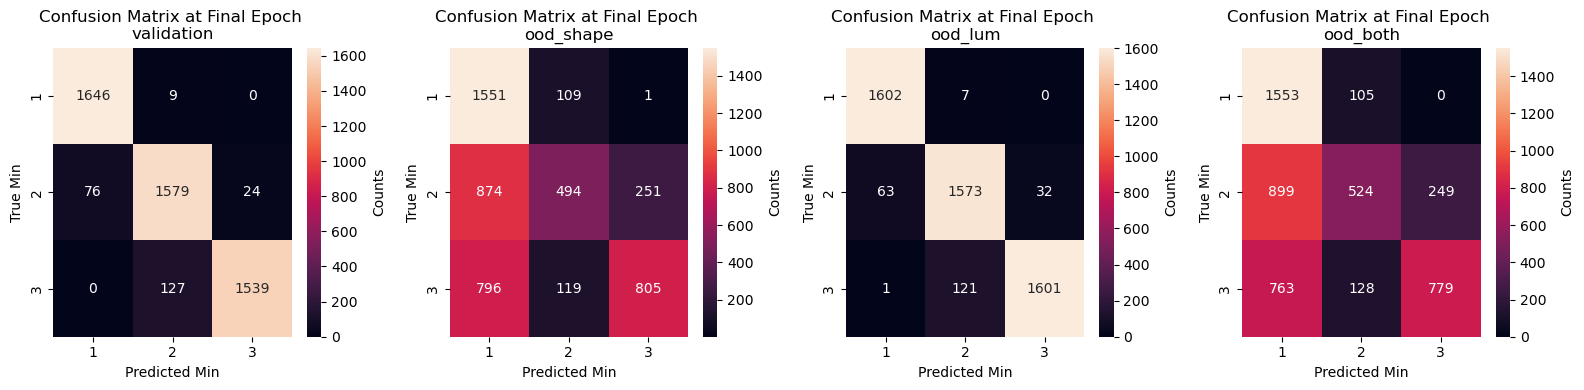

In [20]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

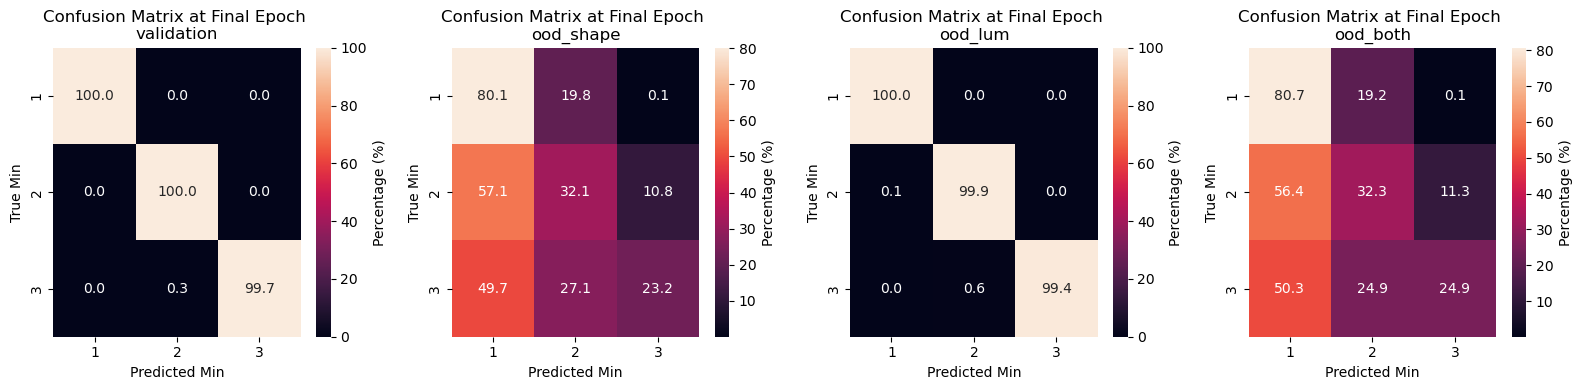

In [162]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c*100 / c.sum(axis=1, keepdims=True), annot=True, fmt=".1f", ax=ax, 
                cbar_kws={'label': 'Percentage (%)'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

<xarray.Dataset> Size: 5GB
Dimensions:                   (image: 40000, glimpse: 12, coordinate: 2,
                               character: 25, slot: 36, coordinates: 2,
                               ground: 2, row: 48, column: 42)
Coordinates:
  * image                     (image) int64 320kB 0 1 2 3 ... 9997 9998 9999
  * glimpse                   (glimpse) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * coordinate                (coordinate) <U1 8B 'x' 'y'
  * character                 (character) int64 200B 0 1 2 3 4 ... 21 22 23 24
  * slot                      (slot) int64 288B 0 1 2 3 4 5 ... 31 32 33 34 35
Dimensions without coordinates: coordinates, ground, row, column
Data variables: (12/24)
    glimpse_coords_1x1        (image, glimpse, coordinate) float32 4MB ...
    symbolic_shape            (image, glimpse, character) float32 48MB ...
    numerosity_target         (image) int64 320kB ...
    numerosity_dist           (image) int64 320kB ...
    numerosity_min            (image

<Axes: ylabel='Count'>

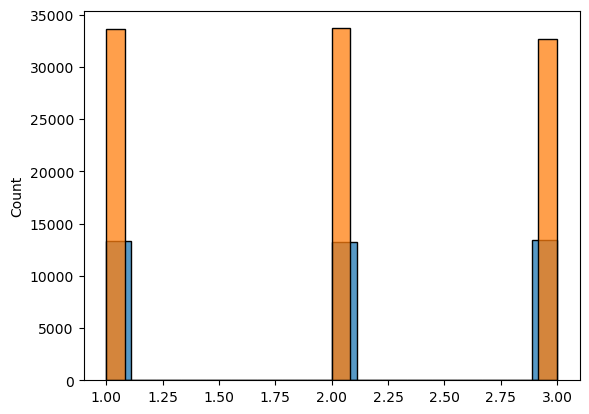

In [28]:
#check the distribution of min values in the dataset
import xarray as xr
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ds_dir = "minmaxdatasets/image_sets_min_max_min7_max7"
ds_files = glob.glob(os.path.join(ds_dir, "*_40000.nc"))
ds_path = ds_files[0]
ds = xr.open_dataset(ds_path)

print(ds)

# plot the distribution of min values in the dataset
sns.histplot(ds["numerosity_min"].values)

vals, counts = np.unique(ds["numerosity_min"].values, return_counts=True)
counts/counts.sum()


# run a simulation to see if doing the inverse will give a uniform distribution
n_samples = 100000
probs = 1/ counts
probs = probs / probs.sum()
samples = np.random.choice(vals, size=n_samples, p=probs)
sns.histplot(samples)



/tmp/ipykernel_7471/1483866307.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])


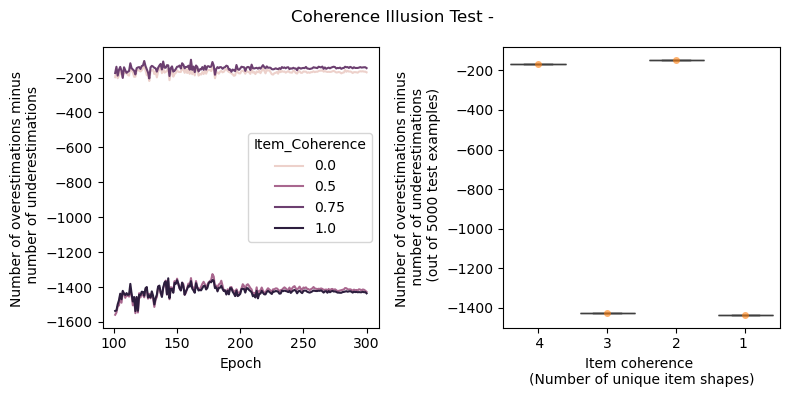

In [29]:
for conf_file in conf_files:
    conf = np.load(conf_file) # conf is of shape (n_epochs+1, 4, n_classes, n_classes)
    match = pattern.search(conf_file)
    res_name = ""
    if match:
        task_type = match.group(1)       # 'min' or 'max'
        loss_type = match.group(2)   # 'num'
        res_name = f"{task_type} task, {loss_type} loss"

    entries = []
    for ep, mat in enumerate(conf):
        # [diff1_loader, diff06_loader, diff03_loader, same_loader]
        diff_conf = mat[0, :, :]
        diff06_conf = mat[1, :, :]
        diff03_conf = mat[2, :, :]
        same_conf = mat[3, :, :]

        diffover = diff_conf[np.triu_indices_from(diff_conf, k=1)].sum()
        diffunder = diff_conf[np.tril_indices_from(diff_conf, k=-1)].sum()
        diff06over = diff06_conf[np.triu_indices_from(diff06_conf, k=1)].sum()
        diff06under = diff06_conf[np.tril_indices_from(diff06_conf, k=-1)].sum()
        diff03over = diff03_conf[np.triu_indices_from(diff03_conf, k=1)].sum()
        diff03under = diff03_conf[np.tril_indices_from(diff03_conf, k=-1)].sum()
        sameover = same_conf[np.triu_indices_from(same_conf, k=1)].sum()
        sameunder = same_conf[np.tril_indices_from(same_conf, k=-1)].sum()
        entries.append({'Item_Coherence':0, 'Over-Under': diffover-diffunder, 'Epoch':ep})
        entries.append({'Item_Coherence':2/4, 'Over-Under': diff06over-diff06under, 'Epoch':ep})
        entries.append({'Item_Coherence':3/4, 'Over-Under': diff03over-diff03under, 'Epoch':ep})
        entries.append({'Item_Coherence':1, 'Over-Under': sameover-sameunder, 'Epoch':ep})
    

    df = pd.DataFrame(entries)
    fig_ill, axes_ill = plt.subplots(1,2, figsize=(8,4))
    sns.lineplot(data=df[df.Epoch>100], y='Over-Under', x='Epoch', hue='Item_Coherence', ax=axes_ill[0])
    #axes_ill[0].set_title('Coherence Illusion Test')
    axes_ill[0].set_ylabel('Number of overestimations minus \n number of underestimations')

    last_epoch = df[df.Epoch==300]
    sns.boxplot(data=last_epoch, y='Over-Under', x='Item_Coherence', ax=axes_ill[1])
    sns.stripplot(data=last_epoch, y='Over-Under', x='Item_Coherence', ax=axes_ill[1], dodge=True, alpha=0.6)
    ticks = [-40, -20, 0, 20, 40]
    # ax.set_yticks(ticks, labels=[t/50 for t in ticks])
    axes_ill[1].set_ylabel('Number of overestimations minus \n number of underestimations \n (out of 5000 test examples)')
    # ax.set_title('Coherence illusion test')
    axes_ill[1].set_xlabel('Item coherence \n(Number of unique item shapes)')
    axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])

    fig_ill.suptitle(f'Coherence Illusion Test - {res_name}')
    plt.tight_layout()



# Saved Trained model

In [ ]:
import torch
model_dir = "models_min7_max7/logpolar"
model_file = glob.glob(os.path.join(model_dir, "pretrained_ventral*.pt"))[0]
model_file
ventral_model_file = glob.glob(os.path.join(model_dir,"ventral","*.pt"))[0]
ventral_model_file
saved_model = torch.load(model_file)


'models_min7_max7/logpolar/ventral/ventral_cnn-lrelu_hsize-25_logpolar_num7-7_nl-0.74_diff-0-6_grid6_policy-cheat+jitter_lum-[0.1, 0.4, 0.7, 0.3, 0.6, 0.9]_trainshapes-BCDEFGHJ__logpolar_40000_loss-mse_opt-Adam_drop0.4_200eps_rep0_ep-200.pt'

In [ ]:
saved_model = torch.load(model_file)


In [ ]:
# instantiate the model class and load the state dict
from models import PretrainedVentral

mod_args = {'h_size': 25, 'act': False,
            #'detach': config.detach, 'format':config.shape_input,
            'n_classes':3, 'dropout': 0.4, 
            'grid': 6,
            'n_shapes':25, 
            'ventral':ventral_model_file, 
            'train_on':"both",
            'finetune': False, 
            'device':'cuda', 
            'sort':False,
            'no_pretrain': False, 
            'whole':False,
            'n_glimpses': 12, 
            'xy_sz':2, 
            'mult':True, 
            'pass_penult':False, 
            'sigmoid':True
            }
sh_sz = np.prod(ds['noised_image'].values[0].shape)
model = PretrainedVentral(sh_sz, 25, 6**2, mod_args['n_classes'], **mod_args).to(mod_args['device'])


Loading saved ventral model parameters...


/home/liangz/VisRel/saccades/models.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.ventral = torch.load(ventral_file)


In [ ]:
saved_model = torch.load(model_file)
saved_model.forward()

/tmp/ipykernel_7471/4152433748.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_model = torch.load(model_file)


PretrainedVentral(
  (ventral): ConvNet(
    (LReLU): LeakyReLU(negative_slope=0.1)
    (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (conv3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (fc1): Linear(in_features=15120, out_features=50, bias=True)
    (fc2): Linear(in_features=50, out_features=10, bias=True)
    (fc3): Linear(in_features=10, out_features=8, bias=True)
    (drop_layer): Dropout(p=0.4, inplace=False)
  )
  (rnn): RNNClassifier2stream(
    (pix_embedding): Linear(in_features=10, out_features=512, bias=True)
    (xy_embedding): Linear(in_features=2, out_features=512, bias=True)
    (joint_embedding): Linear(in_features=1024, out_features=1024, bias=True)
    (rnn): RNN(
      (act_fun): LeakyReLU(negative_slope=0.1)
      (i2h): Linear(in_features=2048, out_features=1024, bias=True)
      (h2o): Linear(in_features=1024, out_features=1024, bias=True)
    )
    (drop_layer): Dropout(p=0.

In [47]:
saved_model.rnn

RNNClassifier2stream(
  (pix_embedding): Linear(in_features=10, out_features=512, bias=True)
  (xy_embedding): Linear(in_features=2, out_features=512, bias=True)
  (joint_embedding): Linear(in_features=1024, out_features=1024, bias=True)
  (rnn): RNN(
    (act_fun): LeakyReLU(negative_slope=0.1)
    (i2h): Linear(in_features=2048, out_features=1024, bias=True)
    (h2o): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (drop_layer): Dropout(p=0.5, inplace=False)
  (map_readout): Linear(in_features=1024, out_features=36, bias=True)
  (num_readout): Linear(in_features=36, out_features=3, bias=False)
  (sigmoid): Sigmoid()
  (LReLU): LeakyReLU(negative_slope=0.1)
)

In [48]:

model.rnn.load_state_dict(saved_model.rnn)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_7471/3517172924.py", line 1, in <module>
    model.rnn.load_state_dict(saved_model.rnn)
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/torch/nn/modules/module.py", line 2516, in load_state_dict
    raise TypeError(
        f"Expected state_dict to be dict-like, got {type(state_dict)}."
    )
TypeError: Expected state_dict to be dict-like, got <class 'models.RNNClassifier2stream'>.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 2194, in showtraceback
    s